# Chapter 9: Machine Learning Intro 1

In [35]:
low_memory=False
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
import seaborn as sns; sns.set()
from sklearn.metrics import confusion_matrix

## 9.1 Introduction & Problem Setting

Let's put everything to the test! Starting with a raw dataset, you'll create a model and evaluate its performance. Then you'll perform proper data processing to see how the results improve! 🌟

Your goal is to predict the spectral class of a new star. You have a dataset containing metrics like size, color, temperature, and more from different stars. The dataset includes the following columns:

- Temperature (K): Absolute Temperature (in K)
- Luminosity (L/Lo): Relative Luminosity (L/Lo)
- Radius (R/Ro): Relative Radius (R/Ro)
- Absolute magnitude (Mv): Absolute Magnitude (Mv)
- Star category: Star Category (Red Dwarf, Brown Dwarf, White Dwarf, Main Sequence, SuperGiants, HyperGiants)
- Star color: Star Color (white, Red, Blue, Yellow, yellow-orange, etc.)
- Spectral Class: Spectral Class (O, B, A, F, G, K, M)
- Spectral Type: Spectral Class encoded as integers

Lo = 3.828 x 10^26 Watts (Average Luminosity of Sun)
Ro = 6.9551 x 10^8 m (Average Radius of Sun)

## 9.2 Creating and evaluating your first model

Create your first model using the data as provided (no modifications yet). Use 'Spectral Class' as your Y variable. Consider which columns are suitable for your model right now and why. Only use those appropriate columns as X.

Evaluate your model by creating a confusion matrix heatmap of your predictions. Remember to use only 25% of your total dataset for testing!

**Make sure to avoid a data leak!**

*Hint: You can use the RandomForest model from the notebook as your starting model.*

In [36]:
star = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Machine Learning 1/Stars.csv",sep=",")
star

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M,5
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M,5
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M,5
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M,5
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M,5
...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O,6
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O,6
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A,0
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A,0


In [37]:
star.shape

(240, 8)

In [38]:
star.dtypes

Temperature (K)              int64
Luminosity (L/Lo)          float64
Radius (R/Ro)              float64
Absolute magnitude (Mv)    float64
Star category               object
Star color                  object
Spectral Class              object
Spectral Type                int64
dtype: object

In [39]:
ML_model = RandomForestClassifier()
ML_model

RandomForestClassifier()

In [40]:
X = star[["Temperature (K)","Luminosity (L/Lo)","Radius (R/Ro)"]]
Y = star["Spectral Class"]

In [41]:
#splitting 25% of the dataset variable
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.25)
ML_model.fit(X_train,Y_train)
y_pred = ML_model.predict(X_test)

Text(92.25, 0.5, 'actual')

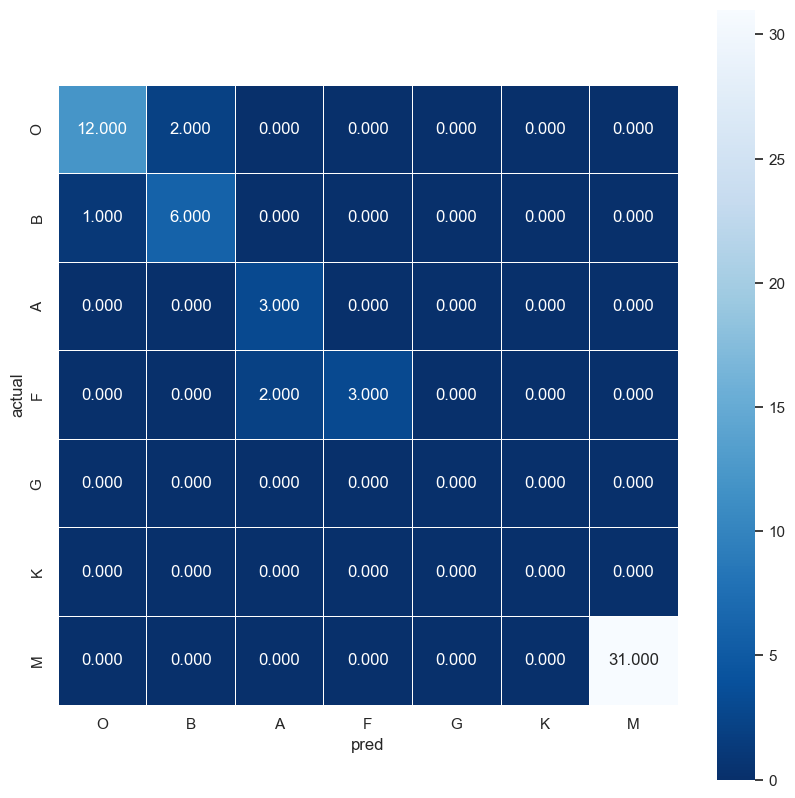

In [42]:
plt.figure(figsize=(10,10))
labels = ['O', 'B', 'A', 'F', 'G', 'K', 'M'] #used ai for spectral classes
sns.heatmap(confusion_matrix(Y_test,y_pred,labels=labels),annot=True,fmt='.3f',linewidths=.5,square=True,cmap='Blues_r',xticklabels=labels,yticklabels=labels)
plt.xlabel("pred")
plt.ylabel("actual")

While a heatmap is useful, it is not always clear which model is better when comparing several of them. That's why we generally use an **accuracy score**. This score tells us how well the model is performing, and how many predictions it has correct. Calculate the accuracy score of your model and interpret it. Is your model any good?

**https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier.score**
```
score = model.score()
```

In [43]:
accuracy = accuracy_score(Y_test,y_pred)
accuracy

0.9166666666666666

## 9.3: Data Processing

Explore the data and answer these questions:

- Are there missing values?
- How is the data distributed?
- Is any of the data correlated?

In [44]:
stars_new = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Machine Learning 1/Stars.csv",sep=",")
stars_new

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M,5
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M,5
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M,5
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M,5
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M,5
...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O,6
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O,6
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A,0
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A,0


In [ ]:
stars_new.dtypes

Temperature (K)              int64
Luminosity (L/Lo)          float64
Radius (R/Ro)              float64
Absolute magnitude (Mv)    float64
Star category               object
Star color                  object
Spectral Class              object
Spectral Type                int64
dtype: object

In [ ]:
stars_new.describe() #numerical distribution

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Spectral Type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,3.758333
std,9552.425037,179432.244940,517.155763,10.532512,2.090007
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,5.000000
75%,15055.500000,198050.000000,42.750000,13.697500,5.000000
max,40000.000000,849420.000000,1948.500000,20.060000,6.000000


<Axes: xlabel='Temperature (K)', ylabel='Count'>

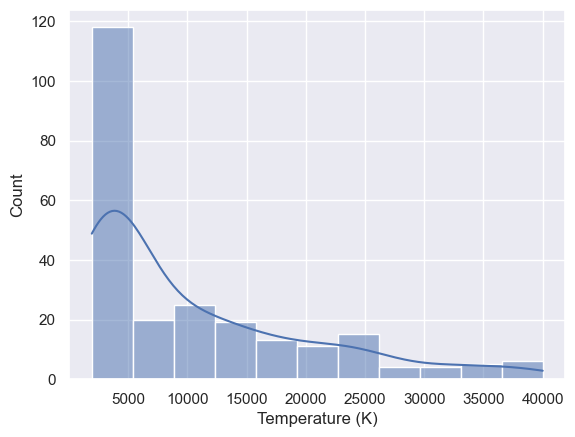

In [ ]:
sns.histplot(stars_new["Temperature (K)"],kde=True) #Skewd dist

<Axes: xlabel='Luminosity (L/Lo)', ylabel='Count'>

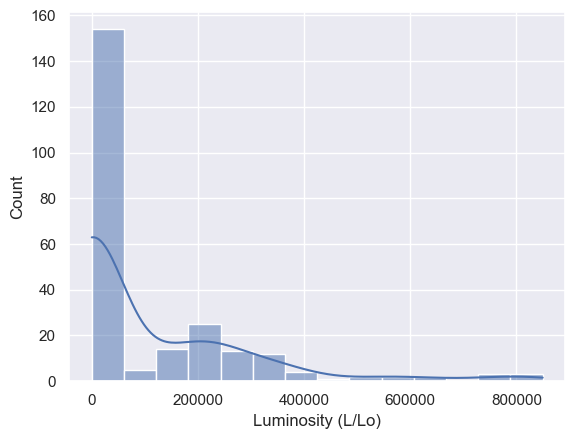

In [ ]:
sns.histplot(stars_new["Luminosity (L/Lo)"],kde=True) #Skewd

In [ ]:
stars_new.isnull().sum() #no missing columns accroding to the output

Temperature (K)            0
Luminosity (L/Lo)          0
Radius (R/Ro)              0
Absolute magnitude (Mv)    0
Star category              0
Star color                 0
Spectral Class             0
Spectral Type              0
dtype: int64

In [ ]:
stars_new.dropna() #incase of a missing value

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Class,Spectral Type
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M,5
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M,5
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M,5
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M,5
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M,5
...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O,6
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O,6
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A,0
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A,0


<Axes: >

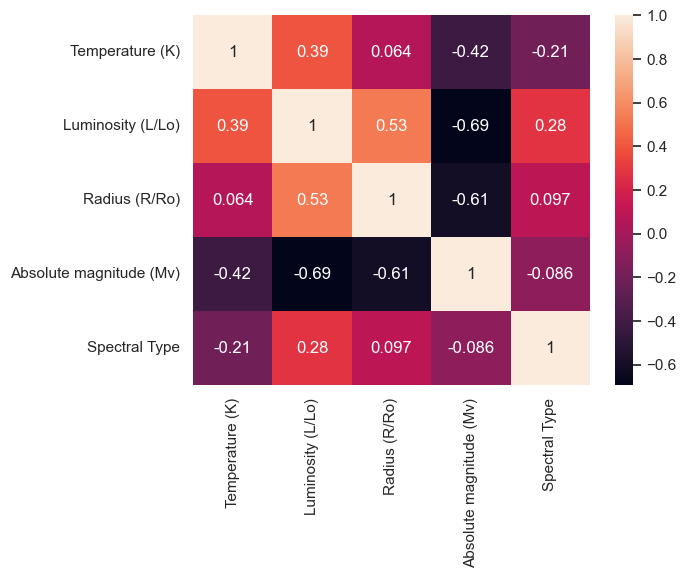

In [ ]:
corr = stars_new.corr(numeric_only=True) #only includes the numerical colums...like temp,lumi,radius etc
sns.heatmap(corr,annot=True) #for the relationship between numerical variables...example - accroding to the heatmap between luminosity and abs magnitude the corr is -0.69 which is strong relation...cuz if lumi increase then abs magnitude will decrease

Based on your observations above, perform the necessary data processing on the dataset. Consider these techniques:

- Handling missing values (imputing or dropping)
- Normalization or standardization
- One-hot encoding
- Other relevant preprocessing

Remember to drop columns that could cause a data leak!

In [ ]:
star_x = pd.get_dummies(stars_new,columns=["Spectral Class"]) #one hot encoding
star_x 

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star category,Star color,Spectral Type,Spectral Class_A,Spectral Class_B,Spectral Class_F,Spectral Class_G,Spectral Class_K,Spectral Class_M,Spectral Class_O
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,5,False,False,False,False,False,True,False
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,5,False,False,False,False,False,True,False
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,5,False,False,False,False,False,True,False
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,5,False,False,False,False,False,True,False
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,5,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,6,False,False,False,False,False,False,True
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,6,False,False,False,False,False,False,True
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,0,True,False,False,False,False,False,False
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,0,True,False,False,False,False,False,False


In [ ]:
#using labelencoding for RF
from sklearn.preprocessing import LabelEncoder
X = stars_new.drop("Spectral Class",axis=1)
x=pd.get_dummies(X)
Y = stars_new["Spectral Class"]
l = LabelEncoder()
y = l.fit_transform(Y)


In [75]:
#train test split
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.25)

Create a new model with your processed dataset. Evaluate it again in the same way as your original model (25% as testing data, heatmap, accuracy score) and compare. What changed?

In [78]:
New_ML_model = RandomForestClassifier()
New_ML_model.fit(X_train,Y_train)

RandomForestClassifier()

In [79]:
y_pred = New_ML_model.predict(X_test)

Text(117.24999999999999, 0.5, 'pred')

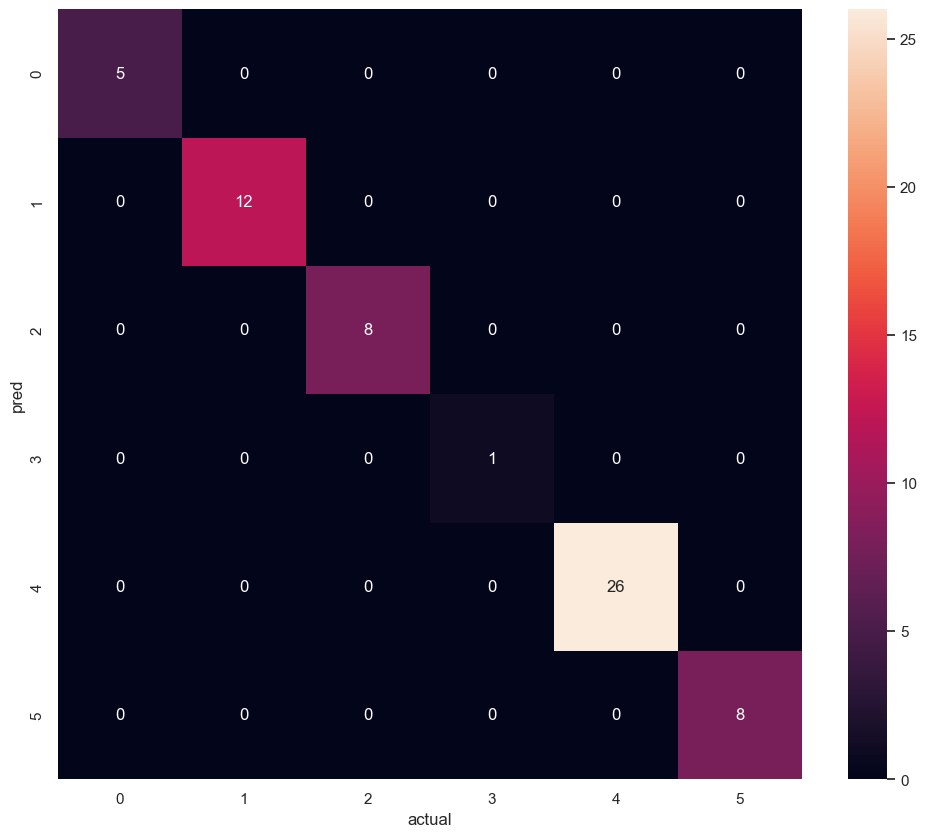

In [89]:
plt.figure(figsize=(12,10))
CM = confusion_matrix(Y_test,y_pred)
sns.heatmap(CM,annot=True)
plt.xlabel("actual")
plt.ylabel("pred")

In [90]:
accuracy = accuracy_score(Y_test,y_pred)
accuracy

1.0